In [1]:
%load_ext autoreload
%autoreload 2

In [37]:
import torch
import torch.optim as optim
import numpy as np
from model import NP_model
from dataset import get_image_dataloader
from train import train

In [75]:
config = {
    'dataset': 'mnist',           # 'mnist' or 'cifar10'
    'max_context_points': 392,  # For MNIST (28x28=784), 392  is 50% of pixels
    'batch_size': 64,
    'num_workers': 4,
    'input_dim_x': 2,             # 2D coordinates (x, y)
    'input_dim_y': 1,             # Grayscale (1 for MNIST, 3 for CIFAR10)
    'hidden_dim': 128*3,
    'output_dim': 1,              # Prediction dimension (1 for MNIST, 3 for CIFAR10)
    'learning_rate': 5e-4,
    'num_epochs': 50,
    'save_every': 10,
    'seed': 42,
}


In [76]:

# Set random seed for reproducibility
torch.manual_seed(config['seed'])
np.random.seed(config['seed'])

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Create dataloaders
print("Loading datasets...")
train_loader = get_image_dataloader(
    dataset_name=config['dataset'],
    batch_size=config['batch_size'],
    num_workers=config['num_workers'],
    train=True,
    flatten=False
)

val_loader = get_image_dataloader(
    dataset_name=config['dataset'],
    batch_size=config['batch_size'],
    num_workers=config['num_workers'],
    train=False,
    flatten=False
)

Loading datasets...
Image dimensions (H, W, C): (28, 28, 1)
Image dimensions (H, W, C): (28, 28, 1)


In [77]:
# Create model
print("\nCreating model...")
model = NP_model(
    input_dim_x=config['input_dim_x'],
    input_dim_y=config['input_dim_y'],
    hidden_dim=config['hidden_dim'],
    output_dim=config['output_dim']
)
model = model.to(device)

# Count parameters
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model has {num_params:,} trainable parameters")

# Create optimizer
optimizer = optim.Adam(model.parameters(), lr=config['learning_rate'])


Creating model...
Model has 452,018 trainable parameters


In [78]:


# Train
print("\n" + "=" * 60)
train_losses, val_losses = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=config['num_epochs'],
    save_dir='checkpoints',
    save_every=config['save_every']
)

# Save training history
np.save('checkpoints/train_losses.npy', train_losses)
np.save('checkpoints/val_losses.npy', val_losses)
print("\nTraining history saved to checkpoints/")


Starting training for 50 epochs...
Device: cuda
Training batches: 938, Validation batches: 157
------------------------------------------------------------


Epoch   1/50 | Train Loss: -1.150732 | Val Loss: -1.728736
  → Saved best model (val_loss: -1.728736)


Epoch   2/50 | Train Loss: -1.631164 | Val Loss: -1.941579
  → Saved best model (val_loss: -1.941579)


Epoch   3/50 | Train Loss: -1.673739 | Val Loss: -1.569137


Epoch   4/50 | Train Loss: -1.675283 | Val Loss: -1.562573


...

Epoch  46/50 | Train Loss: -2.554331 | Val Loss: -2.580450


Epoch  47/50 | Train Loss: -2.572448 | Val Loss: -2.881024


Epoch  48/50 | Train Loss: -2.595548 | Val Loss: -2.670231


Epoch  49/50 | Train Loss: -2.613758 | Val Loss: -2.866578


Epoch  50/50 | Train Loss: -2.708306 | Val Loss: -2.588839
------------------------------------------------------------
Training complete! Best validation loss: -2.900186

Training history saved to checkpoints/


In [79]:
from utils import load_model_from_checkpoint
best_model, checkpoint_info = load_model_from_checkpoint('checkpoints/best_model.pt', config['input_dim_x'], config['input_dim_y'], config['hidden_dim'], config['output_dim'], device='cuda')

Loaded model from checkpoints/best_model.pt
  Epoch: 45
  Train Loss: -2.431834
  Val Loss: -2.900186


<string>:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Image dimensions (H, W, C): (28, 28, 1)


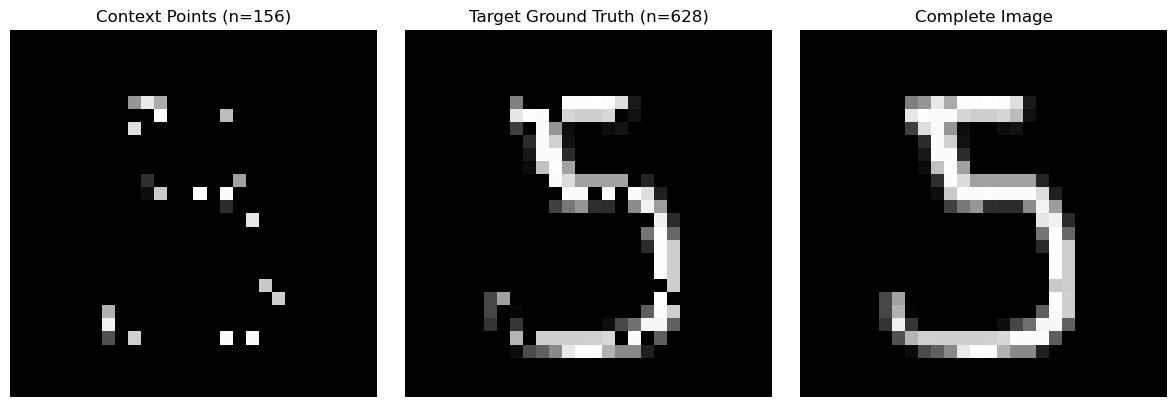

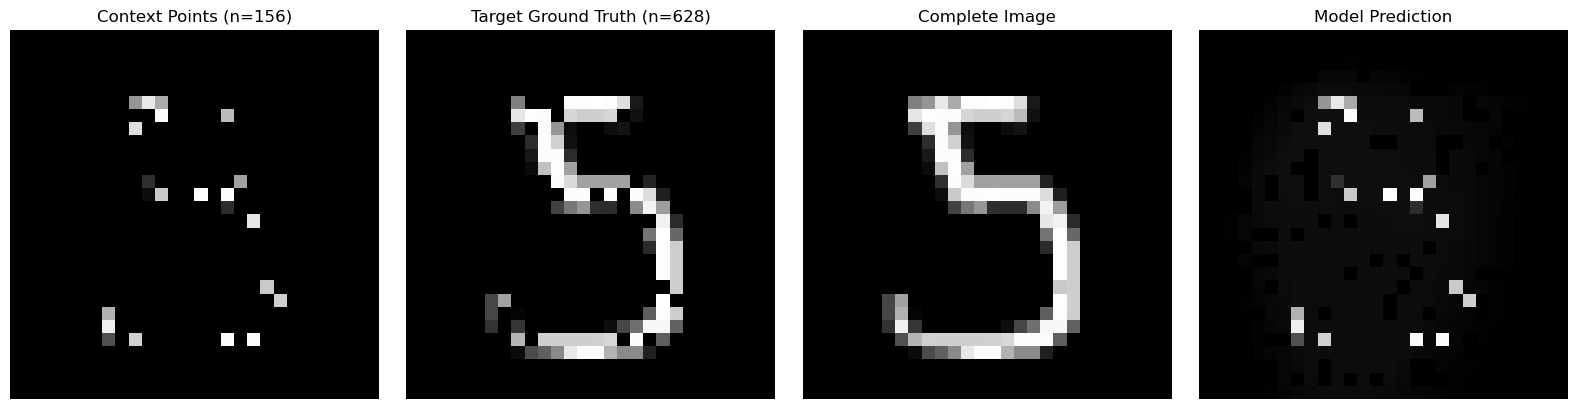

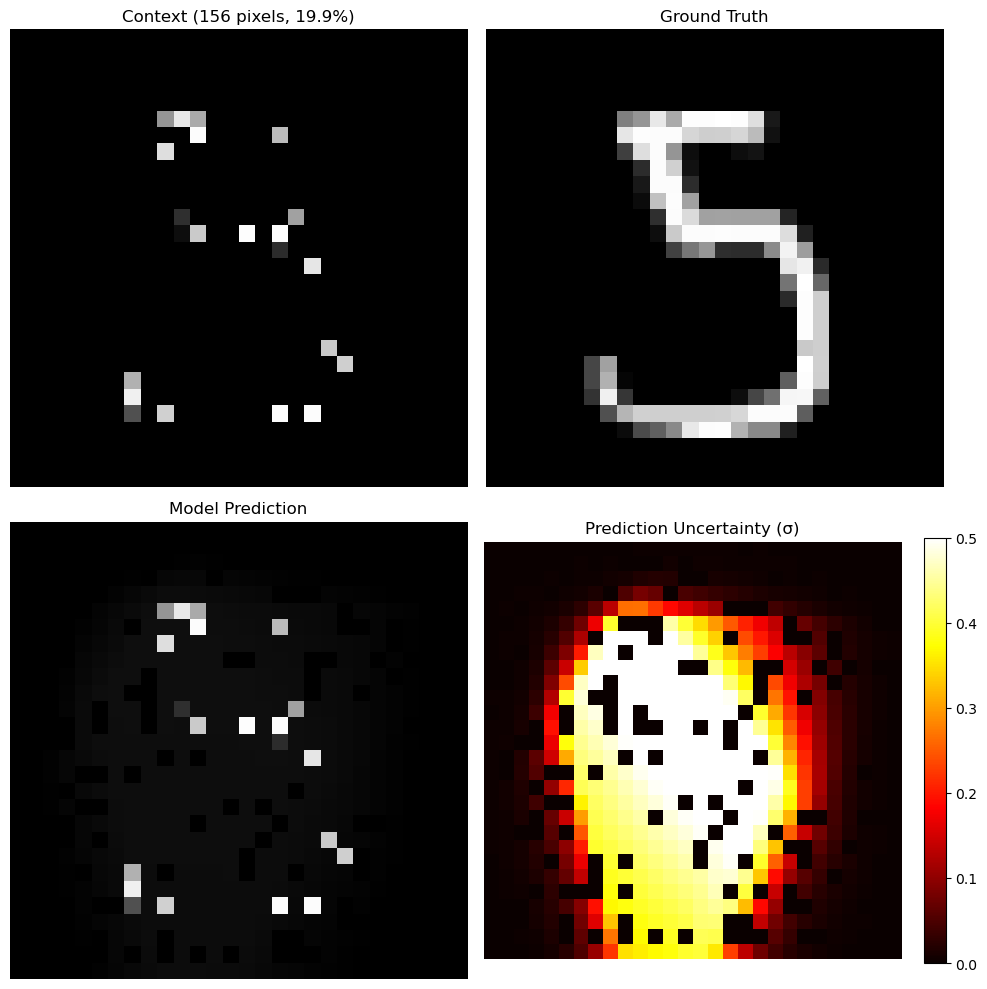

In [82]:
from utils import plot_mnist_sample, plot_prediction_comparison, plot_training_curves
from dataset import get_image_dataloader

# Get a batch
dataloader = get_image_dataloader('mnist', context_ratio=0.2, batch_size=4)
batch = next(iter(dataloader))

# Simple visualization
fig = plot_mnist_sample(batch, batch_idx=0)
plt.show()

# With model predictions
fig = plot_mnist_sample(batch, batch_idx=0, model=best_model, device='cuda')
plt.show()

# Detailed comparison with uncertainty
fig = plot_prediction_comparison(batch, batch_idx=0, model=best_model, device='cuda')
plt.show()

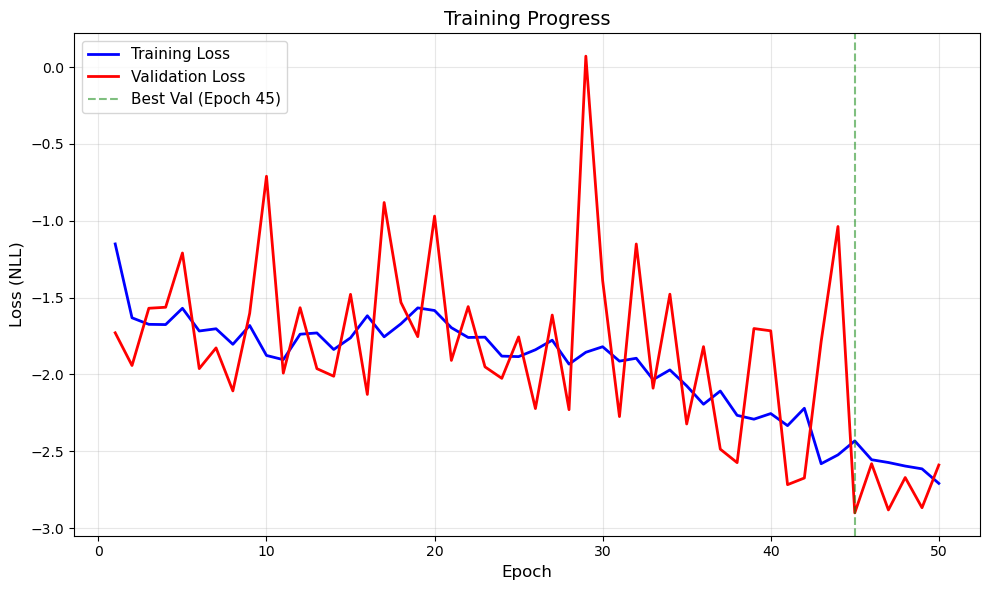

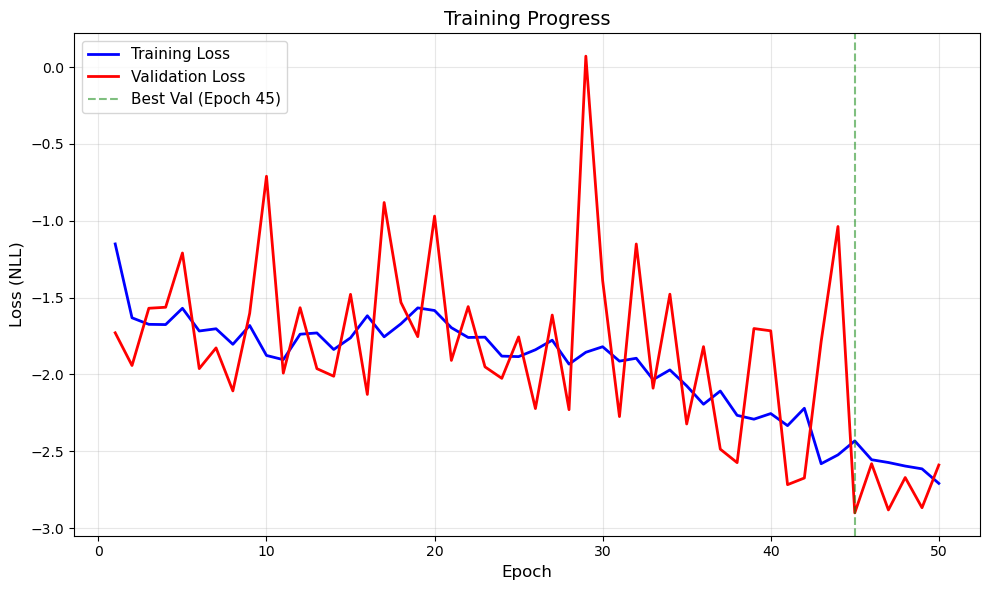

In [81]:
plot_training_curves(train_losses, val_losses)